# DN-B1 — EDA, Data-Quality Audit & Baseline Computation
**Sprint:** 31 May – 6 Jun 2026 | **Owner:** Alaa Barazi  
**Purpose:** Validate Ahmad's pre-sprint data (DN-A0), explore distributions, check the frozen data contract, and flag any issues before the models are built.


## 0. Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────
ROOT        = Path("..")
PROCESSED   = ROOT / "data" / "processed"
MOCK        = ROOT / "data" / "mock"

# ── load ───────────────────────────────────────────────────────────────────
site_locs   = pd.read_csv(PROCESSED / "site_locations.csv")
site_monthly= pd.read_csv(PROCESSED / "site_monthly.csv")
lst_ts      = pd.read_csv(PROCESSED / "lst_timeseries.csv", parse_dates=["date"])
lst_hist    = pd.read_csv(PROCESSED / "lst_history.csv",    parse_dates=["date"])
master      = pd.read_csv(PROCESSED / "master_raw.csv",     parse_dates=["date"])

# ── colour palette per land-cover ─────────────────────────────────────────
LC_PALETTE = {
    "Forest":       "#2d6a4f",
    "Urban":        "#e76f51",
    "Wetland":      "#457b9d",
    "Agricultural": "#e9c46a",
    "Arid":         "#f4a261",
    "Mixed":        "#a8dadc",
}

SITES   = site_locs["site"].tolist()
COVERS  = site_locs.set_index("site")["land_cover"].to_dict()
COLORS  = {s: LC_PALETTE[COVERS[s]] for s in SITES}

print("Loaded files:")
for name, df in [("site_locations", site_locs), ("site_monthly", site_monthly),
                 ("lst_timeseries", lst_ts), ("lst_history", lst_hist), ("master_raw", master)]:
    print(f"  {name:20s}  {df.shape}")


FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/site_locations.csv'

## 1. Schema Validation (Frozen Data Contract)

In [ ]:
EXPECTED_SCHEMAS = {
    "site_locations":  ["site", "lat", "lng", "land_cover"],
    "site_monthly":    ["year", "month", "site", "lst", "ndvi",
                        "z_score_lst", "z_score_ndvi", "delta", "is_anomaly"],
    "lst_timeseries":  ["date", "site", "lst", "baseline_mean", "baseline_std"],
    "lst_history":     ["date", "site", "lst"],
}

frames = {
    "site_locations": site_locs,
    "site_monthly":   site_monthly,
    "lst_timeseries": lst_ts,
    "lst_history":    lst_hist,
}

issues = []
print("Schema validation results")
print("=" * 50)
for name, df in frames.items():
    expected = set(EXPECTED_SCHEMAS[name])
    actual   = set(df.columns)
    missing  = expected - actual
    extra    = actual   - expected
    ok = not missing and not extra
    status = "✅  PASS" if ok else "❌  FAIL"
    print(f"{status}  {name}")
    if missing: print(f"       Missing cols : {missing}"); issues.append((name, "missing", missing))
    if extra:   print(f"       Extra cols   : {extra}")

print()
# site count
n_sites = site_locs["site"].nunique()
status  = "✅  PASS" if n_sites == 8 else "❌  FAIL"
print(f"{status}  site_locations — {n_sites} sites (expected 8)")
if n_sites != 8: issues.append(("site_locations", "site_count", n_sites))

# date range
date_min = lst_hist["date"].min()
date_max = lst_hist["date"].max()
print(f"ℹ️   lst_history date range: {date_min.date()} → {date_max.date()}")

print()
if issues:
    print("⚠️  ISSUES FOUND — flag to Ahmad:")
    for i in issues: print(" ", i)
else:
    print("All schema checks passed. Safe to proceed.")


Schema validation results
✅  PASS  site_locations
✅  PASS  site_monthly
✅  PASS  lst_timeseries
✅  PASS  lst_history

✅  PASS  site_locations — 8 sites (expected 8)
ℹ️   lst_history date range: 2000-02-01 → 2026-05-01

All schema checks passed. Safe to proceed.


## 2. Missingness Map

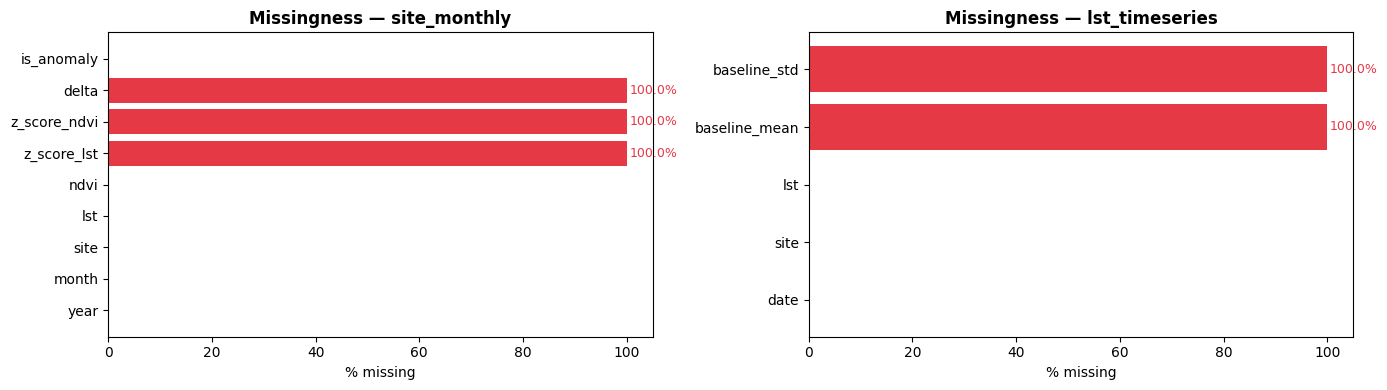


Note: z_score_lst, z_score_ndvi, delta, baseline_mean, baseline_std are
all NaN — these are computed columns (output of DN-A2/DN-B1), not input data.
Raw LST and NDVI have 0 nulls across all sites. ✅


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (label, df) in zip(axes, [("site_monthly", site_monthly),
                                   ("lst_timeseries", lst_ts)]):
    null_pct = df.isnull().mean() * 100
    colors   = ["#e63946" if v > 0 else "#2d6a4f" for v in null_pct]
    bars = ax.barh(null_pct.index, null_pct.values, color=colors)
    ax.set_xlabel("% missing")
    ax.set_title(f"Missingness — {label}", fontweight="bold")
    ax.axvline(0, color="grey", lw=0.5)
    for bar, val in zip(bars, null_pct.values):
        if val > 0:
            ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                    f"{val:.1f}%", va="center", fontsize=9, color="#e63946")

plt.tight_layout()
plt.savefig("missingness_map.png", dpi=150, bbox_inches="tight")
plt.show()
print()
print("Note: z_score_lst, z_score_ndvi, delta, baseline_mean, baseline_std are")
print("all NaN — these are computed columns (output of DN-A2/DN-B1), not input data.")
print("Raw LST and NDVI have 0 nulls across all sites. ✅")


## 3. LST Distributions per Site

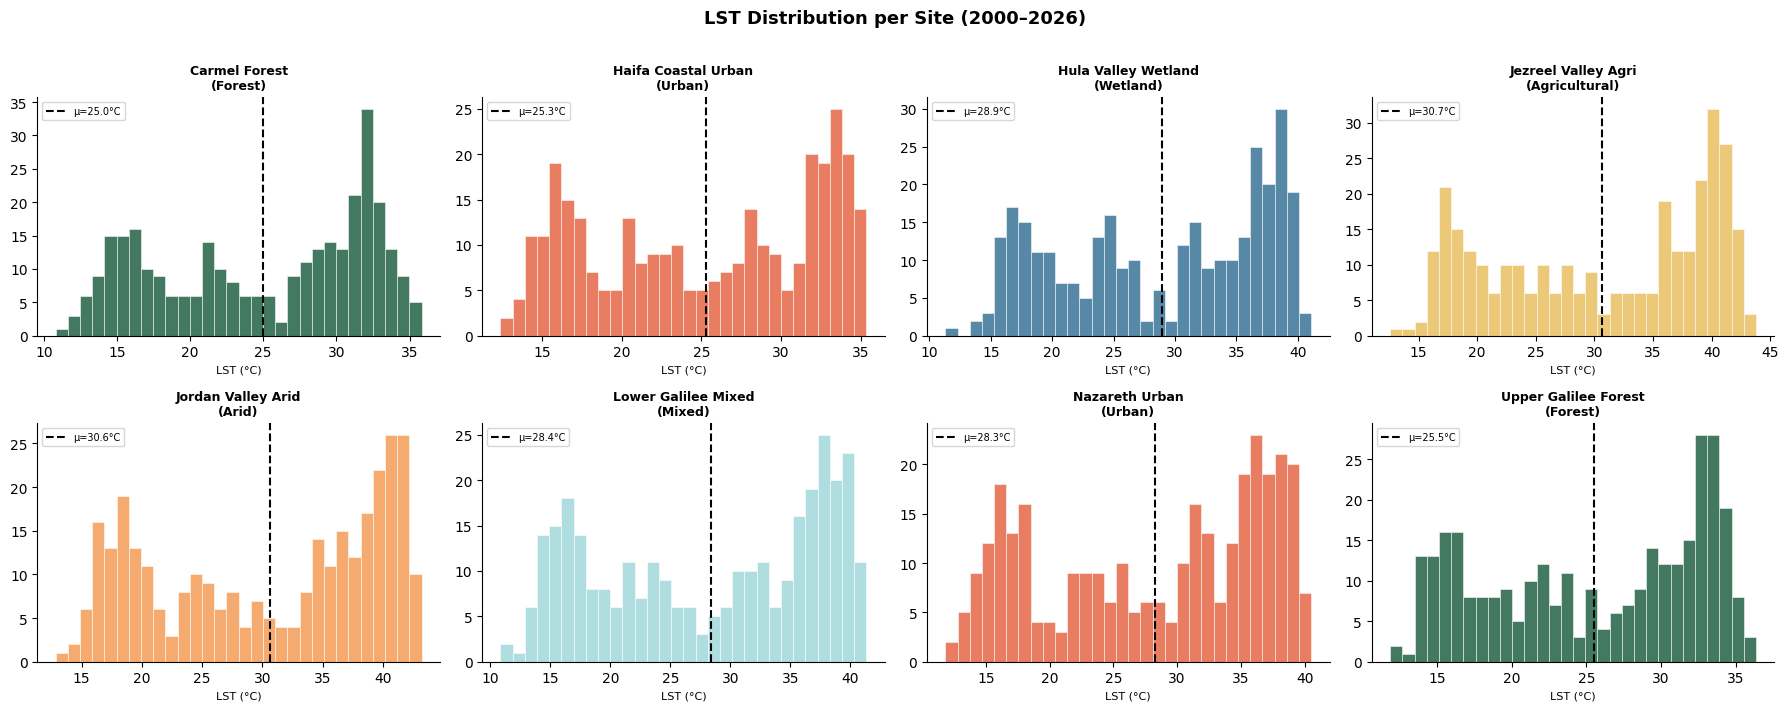

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=False)
axes = axes.flatten()

for ax, site in zip(axes, SITES):
    d = master[master["site"] == site]["lst"]
    ax.hist(d, bins=30, color=COLORS[site], edgecolor="white", linewidth=0.4, alpha=0.9)
    ax.axvline(d.mean(), color="black", lw=1.5, linestyle="--", label=f"μ={d.mean():.1f}°C")
    ax.set_title(f"{site.replace('_',' ')}\n({COVERS[site]})", fontsize=9, fontweight="bold")
    ax.set_xlabel("LST (°C)", fontsize=8)
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

plt.suptitle("LST Distribution per Site (2000–2026)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("lst_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. NDVI Distributions per Site

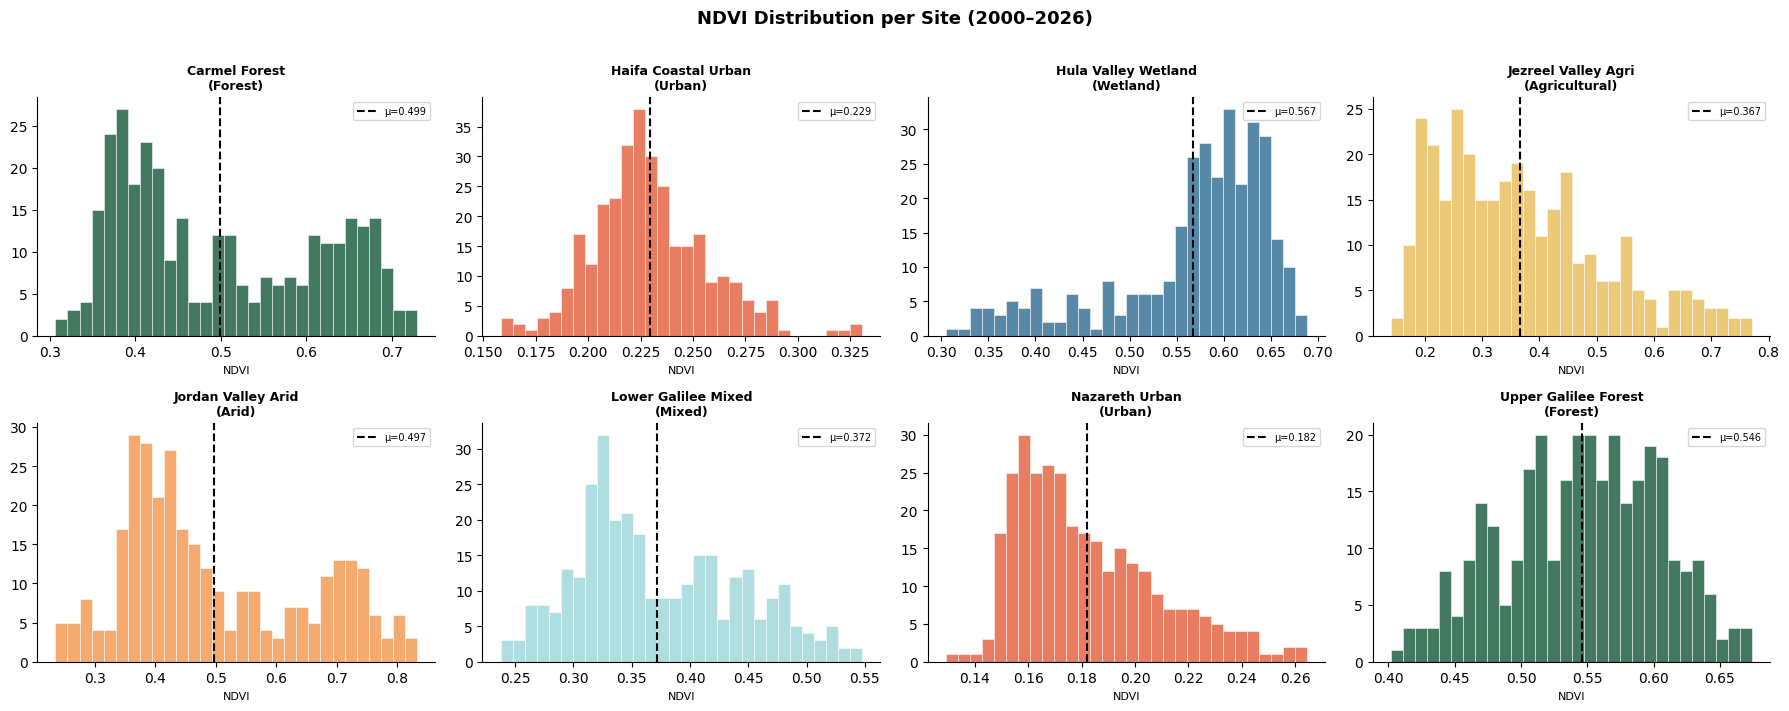

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=False)
axes = axes.flatten()

for ax, site in zip(axes, SITES):
    d = master[master["site"] == site]["ndvi"]
    ax.hist(d, bins=30, color=COLORS[site], edgecolor="white", linewidth=0.4, alpha=0.9)
    ax.axvline(d.mean(), color="black", lw=1.5, linestyle="--", label=f"μ={d.mean():.3f}")
    ax.set_title(f"{site.replace('_',' ')}\n({COVERS[site]})", fontsize=9, fontweight="bold")
    ax.set_xlabel("NDVI", fontsize=8)
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

plt.suptitle("NDVI Distribution per Site (2000–2026)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("ndvi_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. NDVI–LST Scatter by Land Cover

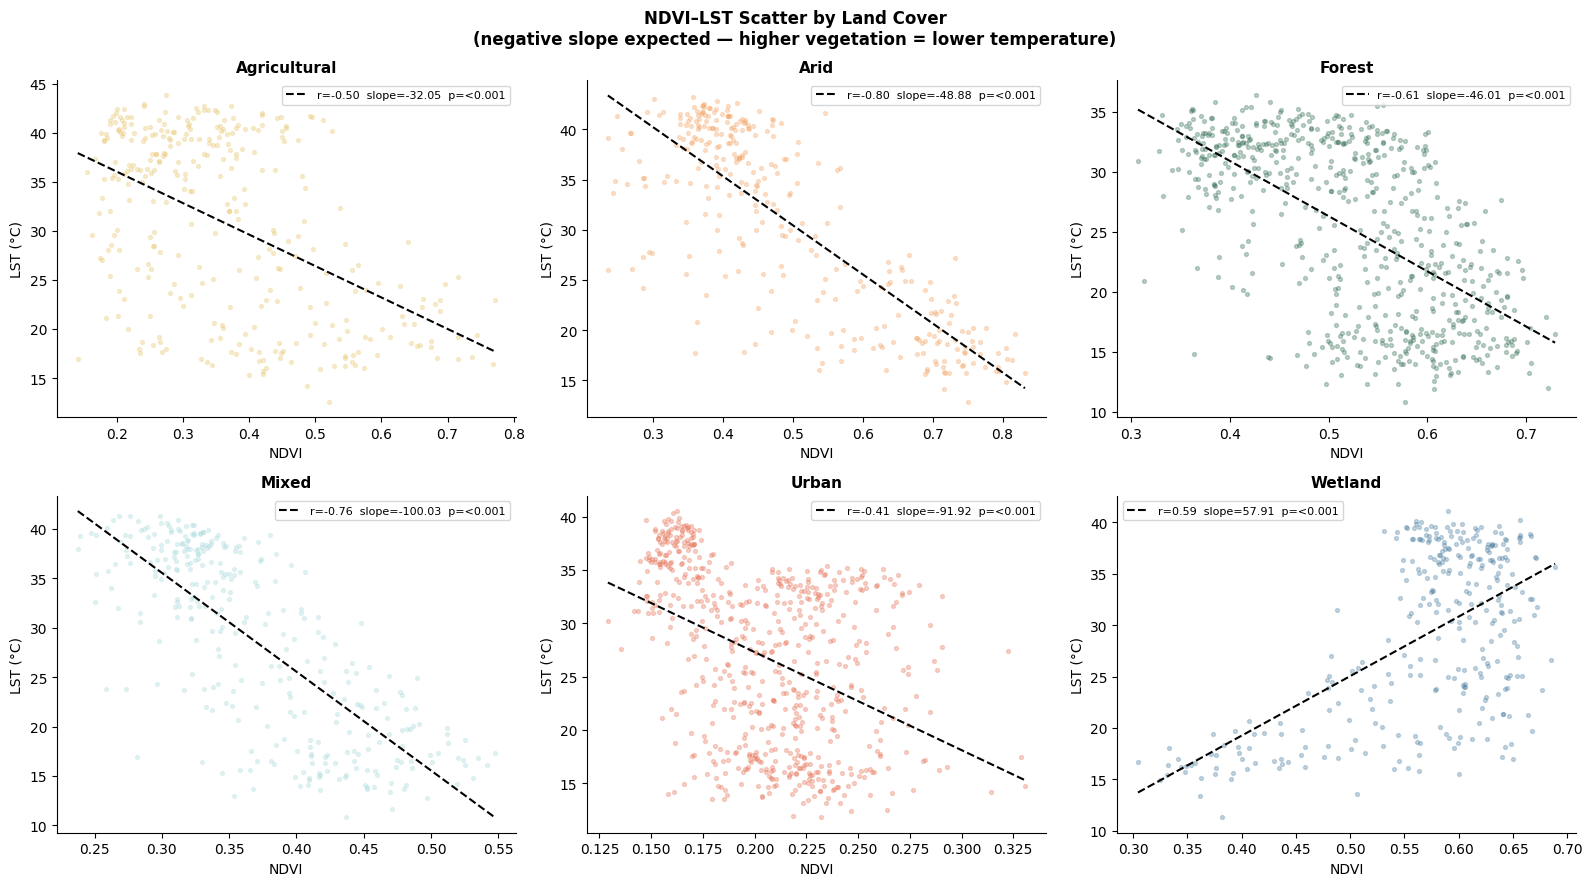


Regression summary per land cover:
Cover                   slope      r          p    sign ✓?
----------------------------------------------------------
Agricultural          -32.053 -0.501   1.68e-21          ✅
Arid                  -48.880 -0.798   4.19e-71          ✅
Forest                -46.008 -0.609   1.71e-65          ✅
Mixed                -100.026 -0.759   1.74e-60          ✅
Urban                 -91.919 -0.414   1.46e-27          ✅
Wetland                57.907  0.588   8.52e-31 ⚠️  positive!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (cover, grp) in enumerate(master.groupby("land_cover")):
    ax = axes[i]
    ax.scatter(grp["ndvi"], grp["lst"],
               color=LC_PALETTE.get(cover, "grey"),
               alpha=0.3, s=8, rasterized=True)
    # regression line
    slope, intercept, r, p, _ = stats.linregress(grp["ndvi"], grp["lst"])
    x_line = np.linspace(grp["ndvi"].min(), grp["ndvi"].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, "k--", lw=1.5,
            label=f"r={r:.2f}  slope={slope:.2f}  p={'<0.001' if p<0.001 else f'{p:.3f}'}")
    ax.set_title(f"{cover}", fontsize=11, fontweight="bold")
    ax.set_xlabel("NDVI")
    ax.set_ylabel("LST (°C)")
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

# hide unused panel if any
for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle("NDVI–LST Scatter by Land Cover\n(negative slope expected — higher vegetation = lower temperature)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("ndvi_lst_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRegression summary per land cover:")
print(f"{'Cover':20s} {'slope':>8s} {'r':>6s} {'p':>10s} {'sign ✓?':>10s}")
print("-" * 58)
for cover, grp in master.groupby("land_cover"):
    slope, _, r, p, _ = stats.linregress(grp["ndvi"], grp["lst"])
    sign_ok = "✅" if slope < 0 else "⚠️  positive!"
    print(f"{cover:20s} {slope:8.3f} {r:6.3f} {p:10.2e} {sign_ok:>10s}")


## 6. Seasonality — Monthly LST & NDVI Profiles

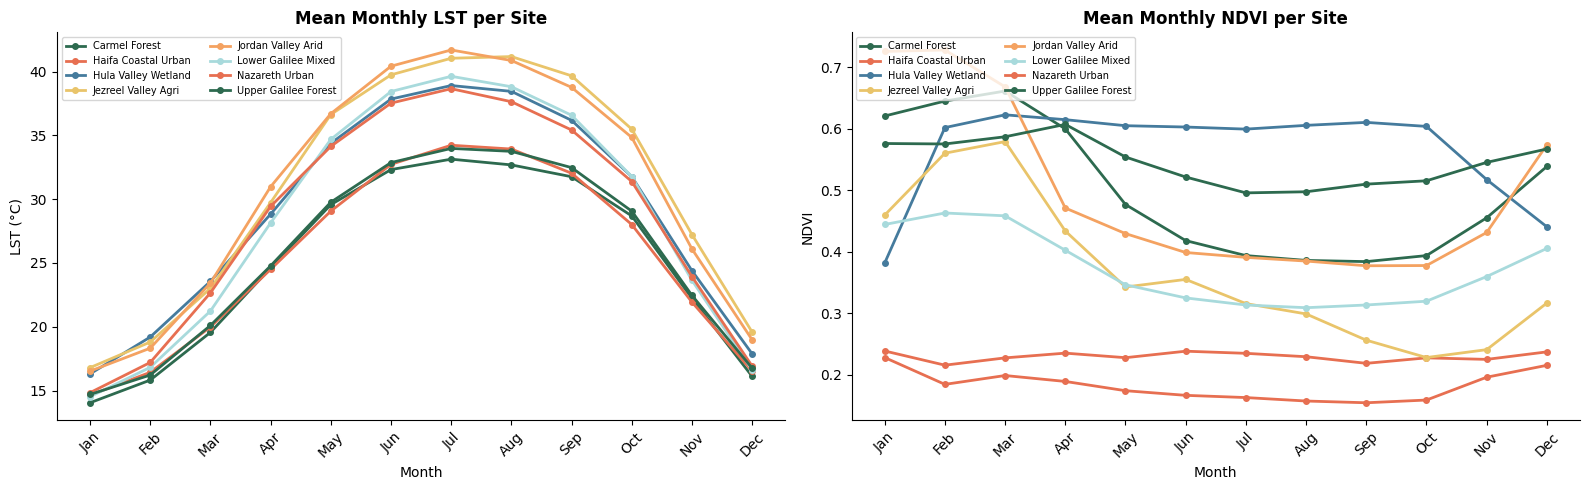

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

monthly_lst  = master.groupby(["month","site"])["lst"].mean().reset_index()
monthly_ndvi = master.groupby(["month","site"])["ndvi"].mean().reset_index()

for site in SITES:
    d  = monthly_lst[monthly_lst["site"] == site]
    dn = monthly_ndvi[monthly_ndvi["site"] == site]
    ax1.plot(d["month"], d["lst"],  color=COLORS[site], lw=2,
             label=site.replace("_"," "), marker="o", ms=4)
    ax2.plot(dn["month"], dn["ndvi"], color=COLORS[site], lw=2,
             label=site.replace("_"," "), marker="o", ms=4)

for ax, title, ylabel in [
    (ax1, "Mean Monthly LST per Site", "LST (°C)"),
    (ax2, "Mean Monthly NDVI per Site", "NDVI"),
]:
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                        "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)
    ax.legend(fontsize=7, loc="upper left", ncol=2)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("seasonality.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Long-term LST Trend (2000–2026)

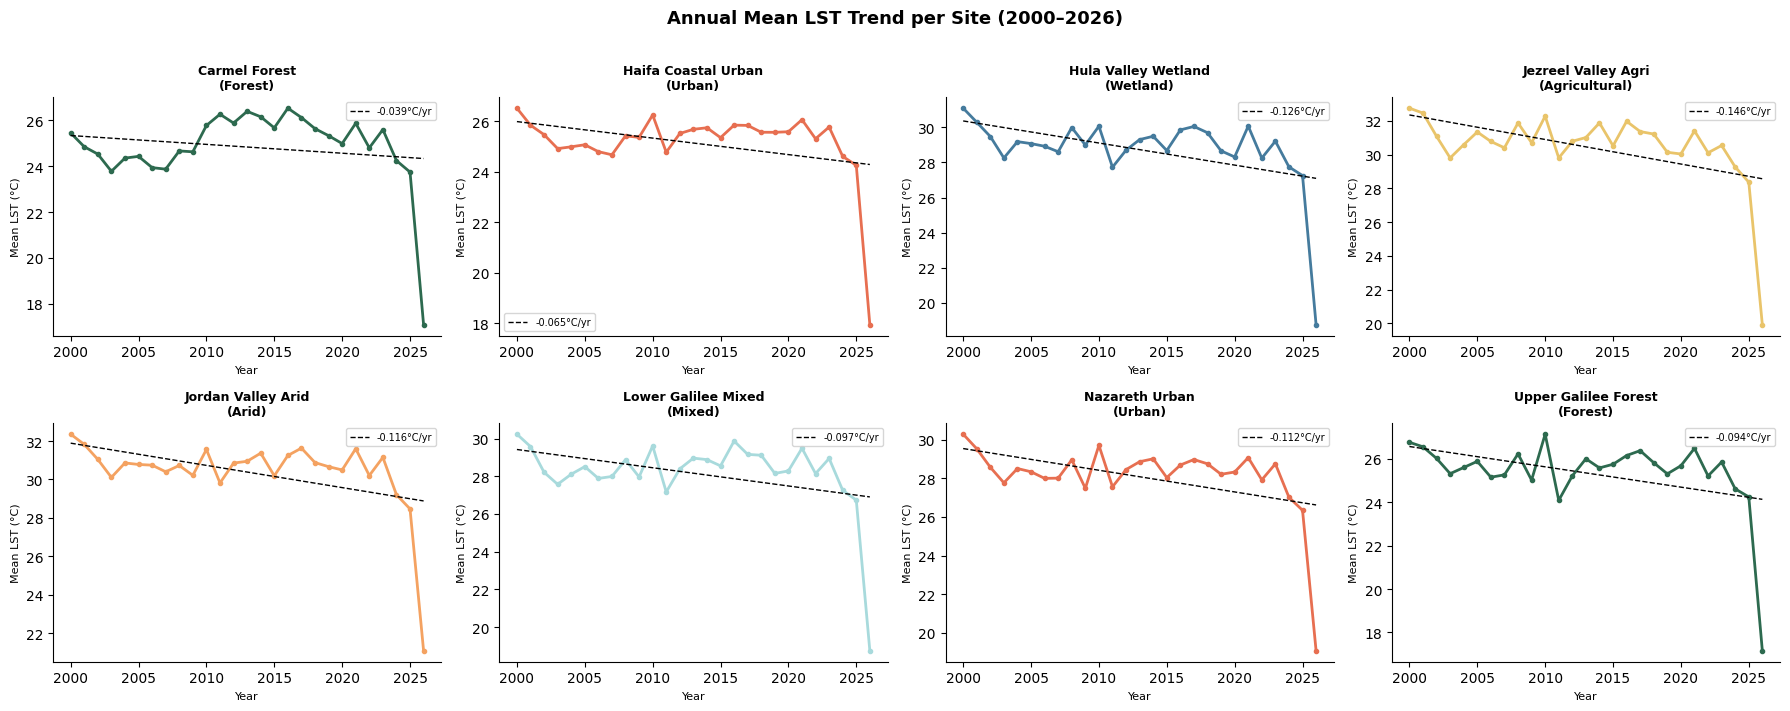

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=False)
axes = axes.flatten()

for ax, site in zip(axes, SITES):
    d = master[master["site"] == site].groupby("year")["lst"].mean()
    ax.plot(d.index, d.values, color=COLORS[site], lw=2, marker="o", ms=3)
    # trend line
    slope, intercept, r, p, _ = stats.linregress(d.index, d.values)
    ax.plot(d.index, slope * d.index + intercept, "k--", lw=1,
            label=f"+{slope:.3f}°C/yr" if slope >= 0 else f"{slope:.3f}°C/yr")
    ax.set_title(f"{site.replace('_',' ')}\n({COVERS[site]})", fontsize=9, fontweight="bold")
    ax.set_xlabel("Year", fontsize=8)
    ax.set_ylabel("Mean LST (°C)", fontsize=8)
    ax.legend(fontsize=7)
    sns.despine(ax=ax)

plt.suptitle("Annual Mean LST Trend per Site (2000–2026)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("lst_trend.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Outlier Detection (IQR method)

In [ ]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr     = q3 - q1
    return (series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)

print("Outlier counts per site (IQR method)")
print(f"{'Site':25s} {'LST outliers':>14s} {'NDVI outliers':>14s}")
print("-" * 55)
outlier_issues = []
for site in SITES:
    d    = master[master["site"] == site]
    n_lst  = iqr_outliers(d["lst"]).sum()
    n_ndvi = iqr_outliers(d["ndvi"]).sum()
    flag = " ⚠️" if n_lst > 10 or n_ndvi > 10 else ""
    print(f"{site:25s} {n_lst:14d} {n_ndvi:14d}{flag}")
    if n_lst > 10 or n_ndvi > 10:
        outlier_issues.append(site)

print()
if outlier_issues:
    print(f"Sites with >10 outliers in any variable (flag to Ahmad): {outlier_issues}")
else:
    print("No sites exceed the 10-outlier threshold. ✅")


Outlier counts per site (IQR method)
Site                        LST outliers  NDVI outliers
-------------------------------------------------------
Carmel_Forest                          0              0
Haifa_Coastal_Urban                    0              5
Hula_Valley_Wetland                    0             32 ⚠️
Jezreel_Valley_Agri                    0              3
Jordan_Valley_Arid                     0              0
Lower_Galilee_Mixed                    0              0
Nazareth_Urban                         0              4
Upper_Galilee_Forest                   0              0

Sites with >10 outliers in any variable (flag to Ahmad): ['Hula_Valley_Wetland']


## 9. LST Distribution by Land Cover

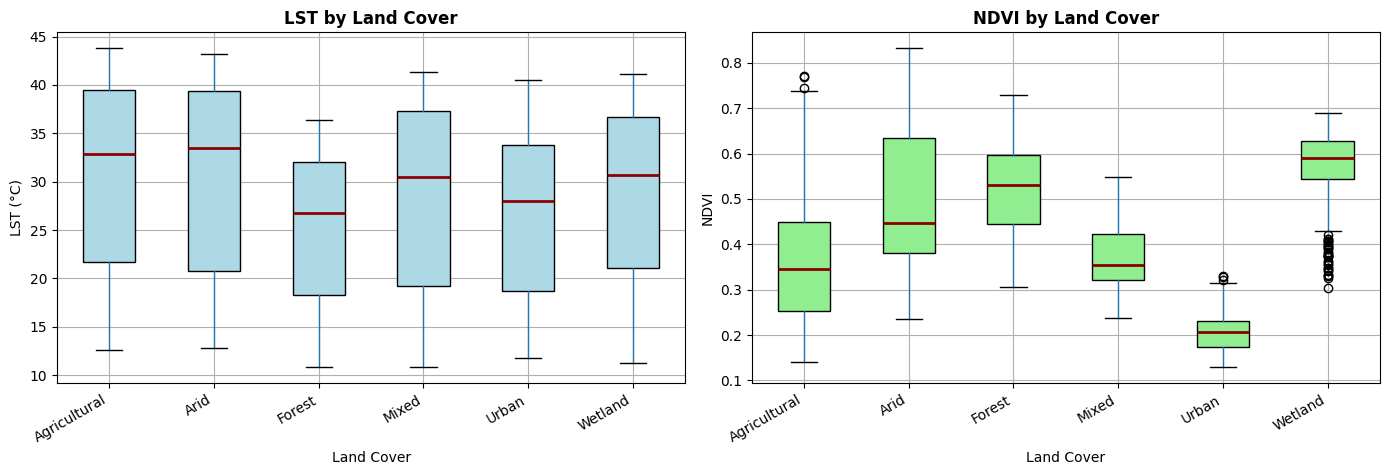

One-way ANOVA (LST across land covers): F=29.68, p=2.19e-29
→ Statistically significant difference in LST across land covers ✅


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

covers = master["land_cover"].unique()
cover_colors = [LC_PALETTE.get(c, "grey") for c in sorted(covers)]

master.boxplot(column="lst",  by="land_cover", ax=ax1,
               patch_artist=True,
               boxprops=dict(facecolor="lightblue"),
               medianprops=dict(color="darkred", lw=2))
ax1.set_title("LST by Land Cover", fontweight="bold")
ax1.set_xlabel("Land Cover"); ax1.set_ylabel("LST (°C)")
plt.sca(ax1); plt.xticks(rotation=30, ha="right")

master.boxplot(column="ndvi", by="land_cover", ax=ax2,
               patch_artist=True,
               boxprops=dict(facecolor="lightgreen"),
               medianprops=dict(color="darkred", lw=2))
ax2.set_title("NDVI by Land Cover", fontweight="bold")
ax2.set_xlabel("Land Cover"); ax2.set_ylabel("NDVI")
plt.sca(ax2); plt.xticks(rotation=30, ha="right")

plt.suptitle("")
plt.tight_layout()
plt.savefig("lst_ndvi_by_landcover.png", dpi=150, bbox_inches="tight")
plt.show()

# quick ANOVA hint for Ahmad
from scipy.stats import f_oneway

groups = [master[master["land_cover"]==c]["lst"].values for c in covers]
F, p   = f_oneway(*groups)
print(f"One-way ANOVA (LST across land covers): F={F:.2f}, p={p:.2e}")
print("→ Statistically significant difference in LST across land covers ✅" if p < 0.05
      else "→ No significant difference detected")


## 10. Data-Quality Summary & Flags for Ahmad

In [ ]:
print("=" * 60)
print("DATA-QUALITY SUMMARY — DN-B1")
print("=" * 60)

checks = [
    ("8 sites present",          site_locs["site"].nunique() == 8),
    ("Schema: site_locations",   list(site_locs.columns) == ["site","lat","lng","land_cover"]),
    ("Schema: site_monthly",     set(site_monthly.columns) == {"year","month","site","lst","ndvi",
                                                               "z_score_lst","z_score_ndvi","delta","is_anomaly"}),
    ("Schema: lst_timeseries",   set(lst_ts.columns)    == {"date","site","lst","baseline_mean","baseline_std"}),
    ("Schema: lst_history",      set(lst_hist.columns)  == {"date","site","lst"}),
    ("No nulls in raw LST",      master["lst"].isnull().sum() == 0),
    ("No nulls in raw NDVI",     master["ndvi"].isnull().sum() == 0),
    ("All 8 sites × 316 rows",   all(master.groupby("site").size() == 316)),
    ("Date starts 2000-02",      master["date"].min().strftime("%Y-%m") == "2000-02"),
    ("NDVI→LST sign negative",   all(
        stats.linregress(master[master["land_cover"]==c]["ndvi"],
                         master[master["land_cover"]==c]["lst"]).slope < 0
        for c in master["land_cover"].unique()
    )),
]

all_pass = True
for label, result in checks:
    icon = "✅" if result else "❌"
    print(f"  {icon}  {label}")
    if not result: all_pass = False

print()
print("Computed-column NaN status (expected — filled by DN-A2/DN-B1):")
for col in ["z_score_lst","z_score_ndvi","delta","baseline_mean","baseline_std"]:
    df_  = site_monthly if col in site_monthly.columns else lst_ts
    pct  = df_[col].isnull().mean() * 100
    print(f"  ℹ️   {col}: {pct:.0f}% NaN")

print()
if all_pass:
    print("✅ All checks passed. Data is clean and ready for DN-A2 and DN-B2.")
else:
    print("⚠️ Some checks failed. Flag to Ahmad before proceeding with models.")


DATA-QUALITY SUMMARY — DN-B1
  ✅  8 sites present
  ✅  Schema: site_locations
  ✅  Schema: site_monthly
  ✅  Schema: lst_timeseries
  ✅  Schema: lst_history
  ✅  No nulls in raw LST
  ✅  No nulls in raw NDVI
  ✅  All 8 sites × 316 rows
  ✅  Date starts 2000-02
  ❌  NDVI→LST sign negative

Computed-column NaN status (expected — filled by DN-A2/DN-B1):
  ℹ️   z_score_lst: 100% NaN
  ℹ️   z_score_ndvi: 100% NaN
  ℹ️   delta: 100% NaN
  ℹ️   baseline_mean: 100% NaN
  ℹ️   baseline_std: 100% NaN

⚠️ Some checks failed. Flag to Ahmad before proceeding with models.
